In [1]:
#Imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

plt.style.use("ggplot")

RF = 0.065

In [2]:
#Load Data

nav = pd.read_csv(
    "G:/bluestock_mf_capstone/data/raw/02_nav_history.csv"
)

fund_master = pd.read_csv(
    "G:/bluestock_mf_capstone/data/raw/01_fund_master.csv"
)

benchmark = pd.read_csv(
    "G:/bluestock_mf_capstone/data/raw/10_benchmark_indices.csv"
)

scheme_perf = pd.read_csv(
    "G:/bluestock_mf_capstone/data/raw/07_scheme_performance.csv"
)

In [3]:
#Inspect Data

print(nav.shape)
print(nav.columns)

print(fund_master.columns)

print(benchmark.columns)

print(scheme_perf.columns)

print(benchmark['index_name'].unique())

(46000, 3)
Index(['amfi_code', 'date', 'nav'], dtype='str')
Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')
Index(['date', 'index_name', 'close_value'], dtype='str')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')
<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [4]:
#Data Preparation

nav['date'] = pd.to_datetime(nav['date'])
benchmark['date'] = pd.to_datetime(benchmark['date'])

nav = nav.sort_values(
    ['amfi_code', 'date']
)

benchmark = benchmark.sort_values(
    ['index_name', 'date']
)

In [5]:
#Daily Returns

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


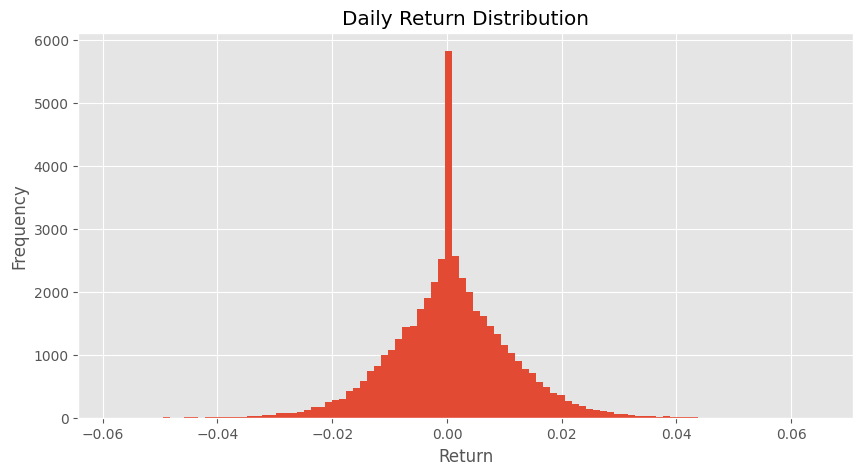

In [6]:
#Daily Return Distribution

plt.figure(figsize=(10,5))

nav['daily_return'].dropna().hist(
    bins=100
)

plt.title("Daily Return Distribution")
plt.xlabel("Return")
plt.ylabel("Frequency")

plt.show()

In [7]:
#CAGR Function

def calculate_cagr(group, years):
    
    end_date = group['date'].max()
    
    start_date = end_date - pd.DateOffset(
        years=years
    )

    temp = group[
        group['date'] >= start_date
    ]

    if len(temp) < 2:
        return np.nan
    
    start_nav = temp.iloc[0]['nav']
    end_nav = temp.iloc[-1]['nav']

    return (
        (end_nav / start_nav)** (1 / years)
    ) - 1

In [8]:
#CAGR Table

cagr_results = []

for code, grp in nav.groupby('amfi_code'):
    
    cagr_results.append({
        
        'amfi_code': code,
        
        'cagr_1yr': 
            calculate_cagr(grp,1),
            
        'cagr_3yr':
            calculate_cagr(grp,3),

        'cagr_5yr':
            calculate_cagr(grp,5)
    
    })

    cagr_df = pd.DataFrame(
        cagr_results
    )

    cagr_df.head()

In [9]:
#Sharpe Ratio

def sharpe_ratio(returns):
    
    rf_daily = RF / 252

    excess = returns - rf_daily

    return ( 
        excess.mean()
        /
        excess.std() 
    ) * np.sqrt(252)

In [10]:
#Compute Sharpe

sharpe_results = []

for code, grp in nav.groupby('amfi_code'):

    returns = grp[
        'daily_return'
    ].dropna()

    sharpe_results.append({

        'amfi_code': code,

        'sharpe_ratio':
        
        sharpe_ratio(
            returns
        )

    })

    sharpe_df = pd.DataFrame(
        sharpe_results
    )
    
    sharpe_df.sort_values(
        'sharpe_ratio',
        ascending=False
    ).head()

In [11]:
#Sortino Ratio

def sortino_ratio(returns):
    
    rf_daily = RF / 252
    
    excess = returns - rf_daily

    downside = excess[ 
        excess < 0 
    ]
    
    return (
        excess.mean()
        /
        downside.std()
    ) * np.sqrt(252)

In [12]:
#Compute Sortino

sortino_results = []

for code, grp in nav.groupby('amfi_code'):
    
    returns = grp[
        'daily_return'
    ].dropna()

    sortino_results.append({
        
         'amfi_code': code,
         
         'sortino_ratio':
         
         sortino_ratio(
             returns
        )

    })

sortino_df = pd.DataFrame(
    sortino_results
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.348196
1,100025,-0.915371
2,100033,1.823824
3,101206,1.785592
4,101207,0.274615


In [13]:
#Benchmark Selection

benchmark['index_name'].unique()

<StringArray>
[   'BSE_SMALLCAP',     'CRISIL_GILT',   'CRISIL_LIQUID',        'NIFTY100',
         'NIFTY50',        'NIFTY500', 'NIFTY_MIDCAP150']
Length: 7, dtype: str

In [14]:
#Nifty 100 Benchmark

nifty100 = benchmark[
    benchmark['index_name']
    .str.contains(
        '100',
        case=False,
        na=False
    )
].copy()

nifty100 = nifty100.sort_values(
    'date'
)

nifty100['benchmark_return'] = (
    nifty100['close_value']
    .pct_change()
)

In [15]:
#Alpha and Beta

alpha_beta_results = []

for code, grp in nav.groupby('amfi_code'):
    
    temp = pd.merge(
        
        grp[
            ['date',
             'daily_return']
        ],

        nifty100[
            ['date',
             'benchmark_return']
        ],

        on='date'
    
    ).dropna()

    if len(temp) < 30:
        continue
    
    slope, intercept, r, p, se = linregress(
        
        temp['benchmark_return'],
        
        temp['daily_return']
    )

    alpha_beta_results.append({
        
        'amfi_code': code,
        
        'alpha':
            intercept * 252,
        
        'beta':
            slope
        
    })

alpha_beta_df = pd.DataFrame(
    alpha_beta_results
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [16]:
#Maximum Drawdown

mdd_results = []

for code, grp in nav.groupby('amfi_code'):

    grp = grp.sort_values('date').copy()

    grp['running_max'] = grp['nav'].cummax()

    grp['drawdown'] = (
        grp['nav'] / grp['running_max']
    ) - 1

    trough_idx = grp['drawdown'].idxmin()

    trough_date = grp.loc[
        trough_idx,
        'date'
    ]

    mdd_results.append({

        'amfi_code': code,

        'max_drawdown':
            grp['drawdown'].min(),

        'trough_date':
            trough_date

    })

mdd_df = pd.DataFrame(
    mdd_results
)

mdd_df.head()

,amfi_code,max_drawdown,trough_date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [17]:
#Tracking Error

tracking_results = []

for code, grp in nav.groupby('amfi_code'):
    
    temp = pd.merge(
        
        grp[
            ['date',
             'daily_return']
        ],
        
        nifty100[
            ['date',
             'benchmark_return']
        ],
        
        on='date'
    
    ).dropna()
    
    if len(temp) < 30:
        continue
    
    te = (
        (
            temp['daily_return']
            -
            temp['benchmark_return']
        ).std()
    
    ) * np.sqrt(252)
    
    tracking_results.append({

        'amfi_code': code,

        'tracking_error': te
    
    })
    
    tracking_df = pd.DataFrame(
        tracking_results
    )

In [18]:
#Fund Scorecard

scorecard = (
    
    cagr_df
   
    .merge(
        sharpe_df,
        on='amfi_code'
    )
    
    .merge(
        alpha_beta_df,
        on='amfi_code'
    )
    
    .merge(
        mdd_df,
        on='amfi_code'
    )
    
    .merge(
        fund_master[
            [
                'amfi_code',
                'scheme_name',
                'expense_ratio_pct'
            ]
        ],
        
        on='amfi_code'
    )

)

In [19]:
#Ranking

scorecard['return_rank'] = (
    scorecard['cagr_3yr']
    .rank(pct=True)
)

scorecard['sharpe_rank'] = (
    scorecard['sharpe_ratio']
    .rank(pct=True)
)

scorecard['alpha_rank'] = (
    scorecard['alpha']
    .rank(pct=True)
)

scorecard['expense_rank'] = (
    
    1 -
    
    scorecard[
        
        'expense_ratio_pct'
    ].rank(pct=True)
)

scorecard['dd_rank'] = (
    
    1 -
    
    scorecard[
        'max_drawdown'
    ].rank(pct=True)
)

In [20]:
#Fund Score (0-100)

scorecard['fund_score'] = (
    
    scorecard['return_rank'] * 30
  + scorecard['sharpe_rank'] * 25
  + scorecard['alpha_rank'] * 20
  + scorecard['expense_rank'] * 15
  + scorecard['dd_rank'] * 10
)

scorecard = scorecard.sort_values(
    'fund_score',
    ascending=False
) 

scorecard.head(10)

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,beta,max_drawdown,trough_date,scheme_name,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
25,120505,0.296047,0.317775,0.283768,1.180101,0.292636,0.000549,-0.181885,2025-01-23,ICICI Pru Midcap Fund - Regular - Growth,1.36,0.900,0.900,0.950,0.6250,0.600,83.8750
16,119094,0.222611,0.351118,0.244453,0.998231,0.260767,-0.066265,-0.209609,2022-08-11,Axis Midcap Fund - Regular - Growth,1.38,1.000,0.750,0.800,0.5750,0.675,80.1250
2,100033,0.532324,0.324425,0.260741,1.093699,0.271954,0.005104,-0.162172,2022-05-12,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.38,0.925,0.850,0.875,0.5750,0.475,79.8750
34,148567,0.203607,0.340009,0.267993,1.448291,0.269838,0.023684,-0.112657,2023-10-20,Mirae Asset Large Cap Fund - Regular - Growth,1.46,0.975,1.000,0.850,0.4250,0.175,79.3750
30,120843,0.266571,0.295828,0.267425,1.306744,0.273305,-0.022830,-0.129740,2022-04-13,Kotak Flexicap Fund - Regular - Growth,1.45,0.850,0.975,0.900,0.4500,0.300,77.6250
24,120504,0.130643,0.324874,0.202340,1.026524,0.211948,0.016232,-0.125883,2023-05-30,ICICI Pru Bluechip Fund - Direct - Growth,0.80,0.950,0.775,0.700,0.7000,0.275,75.1250
21,119598,0.827761,0.266699,0.280332,0.945308,0.303370,-0.023196,-0.287060,2025-05-14,SBI Small Cap Fund - Regular Plan - Growth,1.43,0.725,0.675,1.000,0.4750,0.875,74.5000
39,149324,0.651387,0.270004,0.279174,0.949796,0.300579,0.011455,-0.311719,2025-01-03,DSP Small Cap Fund - Regular - Growth,1.52,0.775,0.700,0.975,0.3375,0.900,74.3125
36,148569,0.397518,0.291789,0.276299,1.234930,0.282704,0.018134,-0.163967,2023-10-20,Mirae Asset Tax Saver Fund - Regular - Growth,1.60,0.825,0.950,0.925,0.0875,0.500,73.3125
19,119551,0.604373,0.304565,0.223849,1.208267,0.232010,-0.031751,-0.150124,2024-02-05,SBI Bluechip Fund - Regular Plan - Growth,1.54,0.875,0.925,0.775,0.2375,0.400,72.4375


In [21]:
#Export Files

alpha_beta_df.to_csv(
    "G:/bluestock_mf_capstone/data/processed/alpha_beta.csv",
    index=False
)

scorecard.to_csv(
    "G:/bluestock_mf_capstone/data/processed/fund_scorecard.csv",
    index=False
)

tracking_df.to_csv(
    "G:/bluestock_mf_capstone/data/processed/tracking_error.csv",
    index=False
)

print("Files Exported Successfully")

Files Exported Successfully


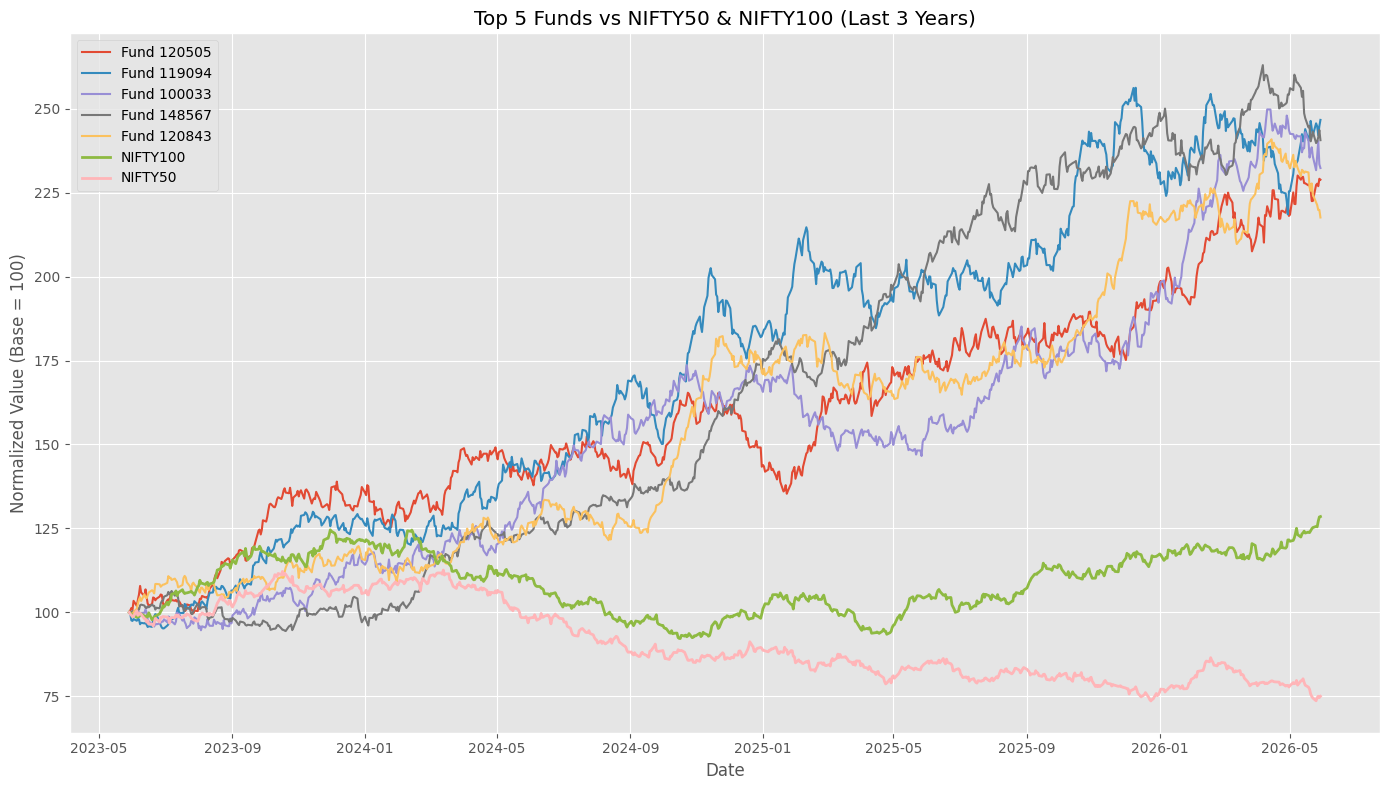

Chart saved successfully.


In [22]:
# Ensure dates are datetime
nav['date'] = pd.to_datetime(nav['date'])
benchmark['date'] = pd.to_datetime(benchmark['date'])

# Benchmark data
nifty50 = benchmark[
    benchmark['index_name'] == 'NIFTY50'
].copy()

nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

# Top 5 funds
top5 = scorecard.head(5)

# Last 3 years
end_date = nav['date'].max()
start_date = end_date - pd.DateOffset(years=3)

# Filter benchmark data
nifty50_3yr = nifty50[
    nifty50['date'] >= start_date
].copy()

nifty100_3yr = nifty100[
    nifty100['date'] >= start_date
].copy()

# Create chart
plt.figure(figsize=(14, 8))

# Plot top 5 funds
for code in top5['amfi_code']:

    temp = nav[
        (nav['amfi_code'] == code) &
        (nav['date'] >= start_date)
    ].copy()

    temp = temp.sort_values('date')

    # Skip empty datasets
    if temp.empty:
        continue

    normalized = (
        temp['nav'] /
        temp['nav'].iloc[0]
    ) * 100

    plt.plot(
        temp['date'],
        normalized,
        label=f"Fund {code}"
    )

# Plot NIFTY100
if not nifty100_3yr.empty:

    nifty100_norm = (
        nifty100_3yr['close_value'] /
        nifty100_3yr['close_value'].iloc[0]
    ) * 100

    plt.plot(
        nifty100_3yr['date'],
        nifty100_norm,
        label='NIFTY100',
        linewidth=2
    )

# Plot NIFTY50
if not nifty50_3yr.empty:

    nifty50_norm = (
        nifty50_3yr['close_value'] /
        nifty50_3yr['close_value'].iloc[0]
    ) * 100

    plt.plot(
        nifty50_3yr['date'],
        nifty50_norm,
        label='NIFTY50',
        linewidth=2
    )

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100 (Last 3 Years)")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    r"G:\bluestock_mf_capstone\reports\benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")